# A TD learner reproduces the dopamine prediction-error signal

A replication of **Schultz, Dayan & Montague (1997), _A Neural Substrate of Prediction and Reward_, Science 275:1593.**

The claim of the paper is that midbrain dopamine neurons do not report reward, they report *error* in the prediction of reward — the same quantity the temporal difference (TD) algorithm computes. Their Fig. 1 shows three response patterns recorded from a monkey; their Fig. 3 shows a TD model producing all three. This notebook is that model, from scratch, in numpy.

Three things should fall out, and all three do:

1. Before learning, the error spikes when the reward arrives.
2. After learning, the spike has moved to the cue, and the reward itself produces nothing.
3. If the reward is then withheld, the error goes negative at exactly the moment the reward was due.

Running every cell top to bottom rewrites the three PNGs in `figures/`. The findings, the places where this version departs from the paper, and what I would try next are in [`writeup.md`](writeup.md).

## The task and the model

The task is the one plotted in the paper's Fig. 3: a trial of 80 time steps, sensory cues at $t=10$ and $t=20$, and a reward of size 1 at $t=60$. Nothing the learner does affects any of this — this is prediction, not control, so there is no policy and no action selection anywhere below.

**What is being learned.** The goal is to predict the discounted sum of reward still to come in the trial (Eq. 1):

$$V(t) \;=\; \mathbb{E}\!\left[\sum_{k \ge 0} \gamma^{k}\, r(t+k)\right], \qquad 0 \le \gamma \le 1$$

which satisfies a consistency condition between adjacent time steps (Eq. 2):

$$V(t) \;=\; \mathbb{E}\big[\,r(t) + \gamma\, V(t+1)\,\big]$$

**The error signal.** The animal cannot wait until the end of the trial to score its prediction, but the violation of that consistency condition is available immediately, one step at a time. That is the TD error (Eq. 3), and it is the quantity the paper identifies with dopamine:

$$\boxed{\;\delta(t) \;=\; r(t) \;+\; \gamma\,\hat{V}(t+1) \;-\; \hat{V}(t)\;}$$

**How a cue is represented.** A single weight per cue would be enough to say *that* reward is coming but not *when*, and the whole result depends on when. So each cue is a **complete serial compound**: a cue with onset $s_i$ is a bank of features $x^{i}_{\tau}$, where $x^{i}_{\tau}(t) = 1$ exactly when $t = s_i + \tau$, each carrying its own weight (Eq. 4):

$$\hat{V}(t) \;=\; \sum_{i}\sum_{\tau} w^{i}_{\tau}\, x^{i}_{\tau}(t) \;=\; \sum_{i} w^{i}_{\,t - s_i}$$

In effect the cue starts a stopwatch, and the model learns a separate prediction for each reading of it.

**The update.** Weights change once per trial, by the correlation between each feature and the error (Eq. 5). Since a serial-compound feature is active at exactly one time step per trial, the sum collapses to a single term:

$$\Delta w^{i}_{\tau} \;=\; \alpha \sum_{t} x^{i}_{\tau}(t)\, \delta(t) \;=\; \alpha\, \delta(s_i + \tau)$$

In [1]:
from dataclasses import dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SEEDS = range(8)
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


@dataclass(frozen=True)
class Config:
    """Task and model parameters.  Defaults follow Fig. 3 of the paper."""

    n_steps: int = 80
    cue_times: tuple = (10, 20)
    reward_time: int = 60
    reward_size: float = 1.0
    alpha: float = 0.1
    gamma: float = 1.0
    n_trials: int = 400

    # Sources of across-seed variability, all off by default.
    reward_sd: float = 0.0  # trial-to-trial jitter in reward magnitude
    omission_prob: float = 0.0  # fraction of training trials with no reward
    timing_jitter: int = 0  # cue-to-reward interval varies by +/- this many steps
    weight_init_sd: float = 0.0  # weights start near zero instead of at zero
    report_noise_sd: float = 0.0  # spike-count noise on the *reported* delta only

    forced_omission_trials: tuple = ()  # trials where reward is withheld regardless

## Where the randomness comes from

A serial-compound TD learner on a fixed task is completely deterministic — run it twice and you get the same number to the last bit — so "run it with a few different seeds" needs somewhere for the seeds to enter. Five candidates, each independently switchable:

| source | what it models | setting |
| --- | --- | --- |
| reward magnitude | the drop of juice is not identical every time | $r \sim \mathcal{N}(1,\, 0.15^2)$ |
| omission | the monkey occasionally misses the reward | withheld on 10% of trials |
| timing jitter | the cue-to-reward interval is not perfectly fixed | $\pm 2$ steps, uniform |
| weight init | the synapses are not exactly zero to begin with | $w \sim \mathcal{N}(0,\, 0.01^2)$ |
| report noise | spike counts are a noisy readout of an underlying rate | $\mathcal{N}(0,\, 0.05^2)$ on the *recorded* $\delta$ |

Report noise is deliberately kept out of the learning signal: it is measurement noise sitting between $\delta(t)$ and the histogram we plot, not part of the error the synapses see. Mixing the two would be a modelling claim rather than a plotting choice, so the code adds it only to the recorded copy.

Timing jitter is different in kind from the other four. It does not perturb the learner, it **changes the task** — the reward genuinely no longer has a fixed time, so no predictor can place it exactly. That turns out to matter a great deal, so the main three-case figure holds timing fixed and jitter gets analysed on its own further down.

In [2]:
NOISE_SOURCES = {
    "reward magnitude": dict(reward_sd=0.15),
    "omission (10%)": dict(omission_prob=0.1),
    "timing jitter": dict(timing_jitter=2),
    "weight init": dict(weight_init_sd=0.01),
    "report noise": dict(report_noise_sd=0.05),
}

# Timing jitter is left out of the main three-case figure: unlike the others it
# changes the task itself, so the model can no longer place the reward exactly.
STOCHASTIC_REWARD = ("reward magnitude", "omission (10%)", "weight init", "report noise")


def with_noise(cfg=Config(), *names):
    """Return a copy of cfg with the named noise sources switched on."""
    settings = {}
    for name in names or NOISE_SOURCES:
        settings.update(NOISE_SOURCES[name])
    return replace(cfg, **settings)

## One indexing detail that the whole result rests on

The serial compound starts at $\tau = 1$, not $\tau = 0$. The paper says so in one clause — *"$x_i(t)$ is 1 exactly $i$ time steps after the presentation of the light"*, with $x_1(s+1) = 1$ — and it is easy to read past, but it is the reason the model has a cue response at all.

Nothing represents the cue at the instant it appears, so $\hat{V}(s) = 0$ forever, while the step after it has learned the full prediction. The error at cue onset is therefore

$$\delta(s) \;=\; \underbrace{r(s)}_{0} \;+\; \gamma\, \underbrace{\hat{V}(s+1)}_{\to\, 1} \;-\; \underbrace{\hat{V}(s)}_{\equiv\, 0} \;\longrightarrow\; \gamma$$

Add a $\tau = 0$ component and $w^{i}_{0}$ simply learns the prediction too, $\hat{V}(s)$ rises to meet $\gamma \hat V(s+1)$, and the onset spike vanishes — there is no longer anything preceding the cue for the model to be surprised by. The phasic response to the CS exists precisely *because* the cue is unrepresented at the moment it arrives. There is a cell near the bottom that runs this variant and shows the response collapsing from 0.99 to 0.008.

Below, `delays[i, t]` holds $\tau$ for cue $i$ at time $t$, or $-1$ where that cue contributes nothing.

In [3]:
def delays_of(cfg):
    """delays[i, t] is the component of cue i active at time t, or -1 if none."""
    t = np.arange(cfg.n_steps)
    delays = np.stack([t - onset for onset in cfg.cue_times])
    return np.where((delays >= 1) & (delays < cfg.n_steps), delays, -1)


def trial(w, cfg, delays, reward_time, reward_size):
    """Run one trial at fixed weights; return V(t), delta(t) and the Eq. 5 update."""
    r = np.zeros(cfg.n_steps)
    if reward_time is not None:
        r[reward_time] = reward_size

    active = delays >= 0
    v = np.zeros(cfg.n_steps + 1)  # v[n_steps] = 0: the trial ends, nothing follows
    per_cue = np.take_along_axis(w, np.maximum(delays, 0), axis=1)
    v[: cfg.n_steps] = np.where(active, per_cue, 0.0).sum(axis=0)

    delta = r + cfg.gamma * v[1:] - v[: cfg.n_steps]

    dw = np.zeros_like(w)
    for i in range(len(cfg.cue_times)):
        on = active[i]
        dw[i, delays[i, on]] = cfg.alpha * delta[on]
    return v[: cfg.n_steps], delta, dw

## Training, and the three probes

`run` trains for `n_trials` and then probes the finished model twice with the weights frozen: once with the reward delivered, once with it withheld. Those two probes plus the very first trial are the three panels of the paper's Fig. 1.

Weights are held fixed *within* a trial and updated once at the end, which is what Eq. 5 literally says. Trial 0 is forced to be rewarded so that the naive panel is always well defined even when omission is switched on.

In [4]:
@dataclass
class Result:
    deltas: np.ndarray  # (n_trials, n_steps) prediction error over training
    values: np.ndarray  # (n_trials, n_steps) value function over training
    weights: np.ndarray  # (n_cues, n_steps) weights after training
    omitted: np.ndarray  # (n_trials,) whether reward was withheld
    naive: np.ndarray  # delta(t) on the first trial
    trained: np.ndarray  # delta(t) after training, reward delivered
    omission: np.ndarray  # delta(t) after training, reward withheld


def run(cfg, seed):
    """Train on cfg for cfg.n_trials, then probe the trained model twice."""
    rng = np.random.default_rng(seed)
    delays = delays_of(cfg)
    shape = (len(cfg.cue_times), cfg.n_steps)
    w = rng.normal(0.0, cfg.weight_init_sd, shape) if cfg.weight_init_sd else np.zeros(shape)

    deltas = np.zeros((cfg.n_trials, cfg.n_steps))
    values = np.zeros((cfg.n_trials, cfg.n_steps))
    omitted = np.zeros(cfg.n_trials, dtype=bool)

    for k in range(cfg.n_trials):
        # Trial 0 is always rewarded so that the naive-case trace is well defined.
        omit = k in cfg.forced_omission_trials or (rng.random() < cfg.omission_prob and k > 0)
        jitter = rng.integers(-cfg.timing_jitter, cfg.timing_jitter + 1)
        reward_time = None if omit else cfg.reward_time + jitter
        reward_size = cfg.reward_size + cfg.reward_sd * rng.standard_normal()

        v, delta, dw = trial(w, cfg, delays, reward_time, reward_size)
        omitted[k] = omit
        values[k] = v
        deltas[k] = delta + cfg.report_noise_sd * rng.standard_normal(cfg.n_steps)
        w += dw  # learning uses delta itself; the recorded trace is the noisy one

    def probe(omit):
        _, delta, _ = trial(w, cfg, delays, None if omit else cfg.reward_time, cfg.reward_size)
        return delta + cfg.report_noise_sd * rng.standard_normal(cfg.n_steps)

    return Result(deltas, values, w, omitted, deltas[0], probe(omit=False), probe(omit=True))


res = run(Config(), seed=0)
for name, delta in (("naive", res.naive), ("trained", res.trained), ("omission", res.omission)):
    print(f"{name:9s} peak |delta| = {np.abs(delta).max():+.3f} at t = {np.abs(delta).argmax()}")

naive     peak |delta| = +1.000 at t = 60
trained   peak |delta| = +0.987 at t = 10
omission  peak |delta| = +1.000 at t = 60


---

# Figure 1 — the three response patterns

The deliverable figure. Eight seeds, drawn as thin grey traces with their mean in black, under the four noise sources that leave the reward time fixed.

What to look for, panel by panel:

- **A, naive.** $\hat V \equiv 0$, so $\delta(60) = r(60) = 1$. The reward is a complete surprise and the error is just the reward.
- **B, trained.** The reward is now fully predicted: $\hat V(60) = 1$ cancels $r(60)$ and $\delta(60) \approx 0$. The spike sits at the first cue instead. Note it is at $t=10$ only — the second cue at $t=20$ is redundant once the first has been learned, which is the paper's prediction that the response transfers to the *earliest* consistent cue, and the same mechanism it offers for blocking.
- **C, omission.** Same trained weights, but $r(60) = 0$, so $\delta(60) = \gamma\hat V(61) - \hat V(60) \approx -1$. The dip lands at the moment the reward was due even though nothing happens there — the timing is carried entirely by the model's internal representation of elapsed time.

naive, delta at reward         +0.912 +/- 0.132
trained, delta at cue          +0.884 +/- 0.033
trained, delta at second cue   +0.023 +/- 0.030
trained, delta at reward       +0.050 +/- 0.079
omission, delta at reward      -0.943 +/- 0.071


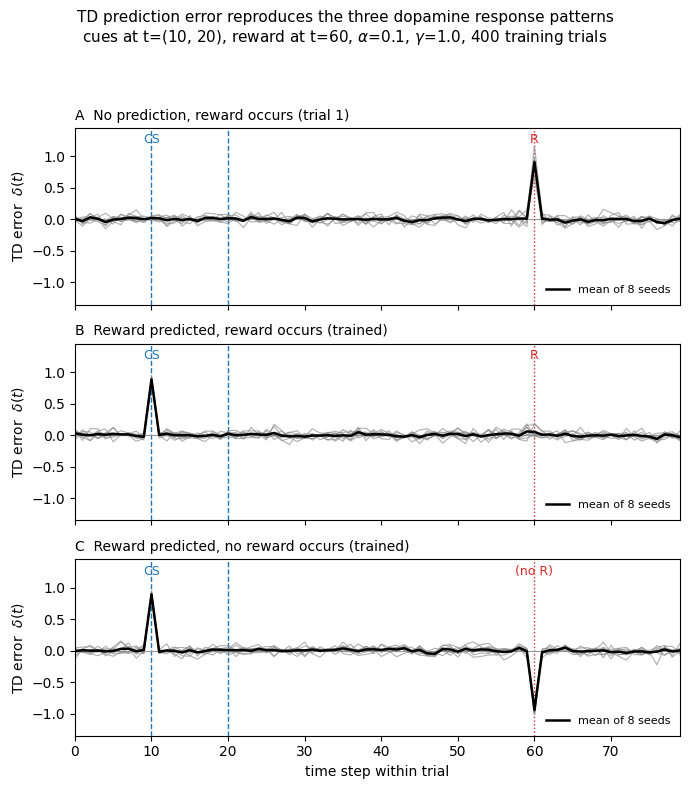

In [5]:
def mark_events(ax, cfg, reward_label="R"):
    for onset in cfg.cue_times:
        ax.axvline(onset, color="tab:blue", lw=1, ls="--", zorder=0)
    ax.axvline(cfg.reward_time, color="tab:red", lw=1, ls=":", zorder=0)
    ax.annotate("CS", (cfg.cue_times[0], 0.97), xycoords=("data", "axes fraction"),
                ha="center", va="top", color="tab:blue", fontsize=9)
    ax.annotate(reward_label, (cfg.reward_time, 0.97), xycoords=("data", "axes fraction"),
                ha="center", va="top", color="tab:red", fontsize=9)


def fig_three_cases(cfg):
    """Fig. 1: naive, trained, and reward-omitted responses across seeds."""
    runs = [run(cfg, seed) for seed in SEEDS]
    panels = [
        ("A  No prediction, reward occurs (trial 1)", [r.naive for r in runs], "R"),
        ("B  Reward predicted, reward occurs (trained)", [r.trained for r in runs], "R"),
        ("C  Reward predicted, no reward occurs (trained)", [r.omission for r in runs], "(no R)"),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(7.0, 8.0), sharex=True, sharey=True)
    for ax, (title, traces, reward_label) in zip(axes, panels):
        traces = np.array(traces)
        mark_events(ax, cfg, reward_label)
        ax.axhline(0, color="0.6", lw=0.8, zorder=0)
        for trace in traces:
            ax.plot(trace, color="0.55", lw=0.8, alpha=0.7, zorder=1)
        ax.plot(traces.mean(axis=0), color="k", lw=1.8, zorder=2,
                label=f"mean of {len(SEEDS)} seeds")
        ax.set_title(title, loc="left", fontsize=10)
        ax.set_ylabel(r"TD error  $\delta(t)$")
        ax.legend(loc="lower right", fontsize=8, frameon=False)

    axes[-1].set_xlabel("time step within trial")
    axes[0].set_xlim(0, cfg.n_steps - 1)
    axes[0].set_ylim(-1.35, 1.45)
    fig.suptitle("TD prediction error reproduces the three dopamine response patterns\n"
                 f"cues at t={cfg.cue_times}, reward at t={cfg.reward_time}, "
                 rf"$\alpha$={cfg.alpha}, $\gamma$={cfg.gamma}, {cfg.n_trials} training trials",
                 fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig, runs


stochastic = with_noise(Config(), *STOCHASTIC_REWARD)
fig, runs = fig_three_cases(stochastic)
fig.savefig(FIGURES / "fig1_three_cases.png", dpi=200)

readouts = {
    "naive, delta at reward": [r.naive[60] for r in runs],
    "trained, delta at cue": [r.trained[10] for r in runs],
    "trained, delta at second cue": [r.trained[20] for r in runs],
    "trained, delta at reward": [r.trained[60] for r in runs],
    "omission, delta at reward": [r.omission[60] for r in runs],
}
for name, values in readouts.items():
    print(f"{name:30s} {np.mean(values):+.3f} +/- {np.std(values):.3f}")

---

# Figure 3 — how the signal gets there

Fig. 1 shows the endpoints; the paper's Fig. 3 shows the journey, as surfaces over (trial, time). Two things are visible in the prediction-error surface: a ridge that starts at the reward and walks backwards to the cue, and the notch cut by a single omitted reward on trial 100.

**Why the ridge walks back exactly one step per trial.** Start from $w = 0$. On trial 0 the only nonzero error is $\delta(60) = 1$, so Eq. 5 raises exactly one weight, the one that fires at $t=60$, by $\alpha$. Now $\hat V(60) = \alpha$, so on trial 1 the step before it is no longer flat:

$$\delta(59) \;=\; \gamma \hat{V}(60) - \hat{V}(59) \;=\; \alpha$$

and *that* weight moves. There is no eligibility trace here, so information crosses one time step per trial and no faster:

$$\hat{V}(t) = 0 \quad \text{until trial } \; 60 - t$$

Bridging the 50 steps from reward to cue therefore costs at least 50 trials **whatever the learning rate is**. $\alpha$ controls how tall the ridge is once it arrives, not how fast it travels.

This also predicts the ordering the paper remarks on — *"the timing of reward delivery is learned well before any response transfers to the earliest sensory cue"* — and the cell below checks it: at $\alpha = 0.1$ the reward-time response is extinguished within a dozen trials while the cue response takes a few hundred to saturate. The surfaces are drawn at $\alpha = 0.5$ so the migration fits into a trial count comparable to the paper's figure.

reward-time response falls below 0.1 at trial 11
cue response first exceeds 0.9 at trial      354


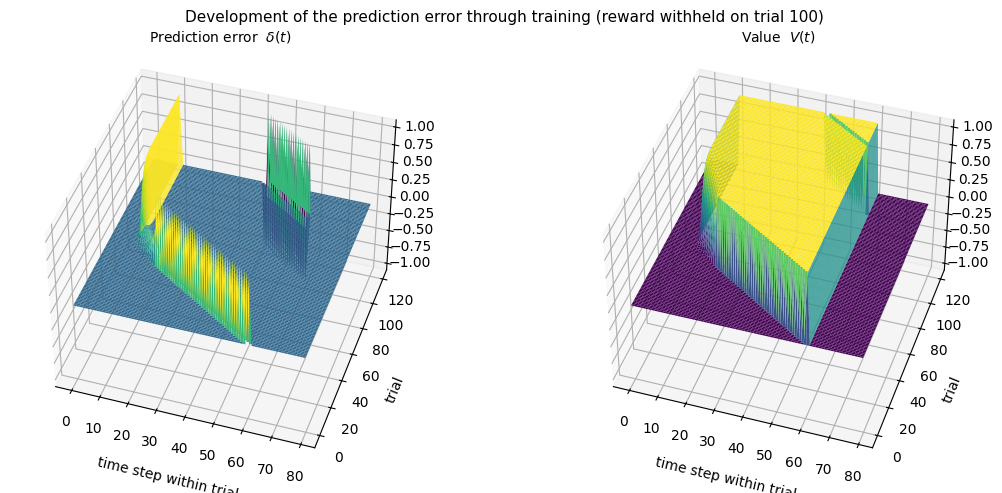

In [6]:
def fig_surfaces(cfg):
    """Fig. 3: prediction error and value as functions of trial and time."""
    res = run(cfg, seed=0)
    trial_grid, time_grid = np.meshgrid(np.arange(cfg.n_trials), np.arange(cfg.n_steps),
                                        indexing="ij")

    fig = plt.figure(figsize=(11.0, 5.0))
    for i, (surface, label) in enumerate(((res.deltas, r"Prediction error  $\delta(t)$"),
                                          (res.values, r"Value  $V(t)$"))):
        ax = fig.add_subplot(1, 2, i + 1, projection="3d")
        ax.plot_surface(time_grid, trial_grid, surface, cmap="viridis", rstride=1, cstride=1,
                        linewidth=0, antialiased=True)
        ax.set_xlabel("time step within trial", labelpad=8)
        ax.set_ylabel("trial", labelpad=6)
        ax.set_title(label, fontsize=10)
        ax.set_zlim(-1.1, 1.1)
        ax.view_init(elev=42, azim=-72)

    omitted = ", ".join(str(k) for k in cfg.forced_omission_trials)
    fig.suptitle("Development of the prediction error through training "
                 f"(reward withheld on trial {omitted})", fontsize=11, y=0.98)
    fig.subplots_adjust(left=0.0, right=0.99, bottom=0.06, top=0.90, wspace=0.05)
    return fig


fig = fig_surfaces(replace(Config(), alpha=0.5, n_trials=120, forced_omission_trials=(100,)))
fig.savefig(FIGURES / "fig3_surfaces.png", dpi=200)

# Is the reward time really learned before the response transfers to the cue?
slow = run(Config(), seed=0)  # alpha = 0.1
print("reward-time response falls below 0.1 at trial",
      int(np.argmax(slow.deltas[:, 60] < 0.1)))
print("cue response first exceeds 0.9 at trial     ",
      int(np.argmax(slow.deltas[:, 10] > 0.9)))

---

# Which source of randomness actually matters

Turning the five sources on one at a time and measuring the spread across seeds. The answer is not close: **timing jitter dominates**, and it does something more interesting than adding variance — it destroys the omission dip outright, which is the one signature of the three that has no direct sensory cause.

**Why, exactly.** Suppose the reward time $T$ is uniform on $\{58, \dots, 62\}$. The serial compound indexes weights by elapsed time alone, so the best predictor available is a function of $t$ only — it cannot condition on whether the reward has already arrived. With $\gamma = 1$ its fixed point is the probability that the reward is still to come:

$$V(t) \;=\; \mathbb{P}(T \ge t) \quad\Longrightarrow\quad V(58..63) = (1.0,\; 0.8,\; 0.6,\; 0.4,\; 0.2,\; 0)$$

so on an omission probe at the nominal reward time the dip is not $-1$ but

$$\delta(60) \;=\; 0 + V(61) - V(60) \;=\; 0.4 - 0.6 \;=\; -0.2$$

The measured value below is $-0.31 \pm 0.22$ across seeds — scattered around the predicted $-0.2$ rather than sitting on it, since the jitter keeps nudging the weights near the reward and they never fully settle. Either way the collapse is the fixed point doing its job, not a convergence artefact. The published figure's clean $-1$ dip is only available to a model that knows the interval to the step.

This is not a criticism of the paper so much as a boundary condition on it, and the paper's own footnote 18 (Hollerman & Schultz) points the same way: in the monkey, depressions appear at the normal reward time only when the reward is genuinely late.

omission dip under +/-2 step jitter: -0.307 +/- 0.221   (fixed point predicts -0.200)


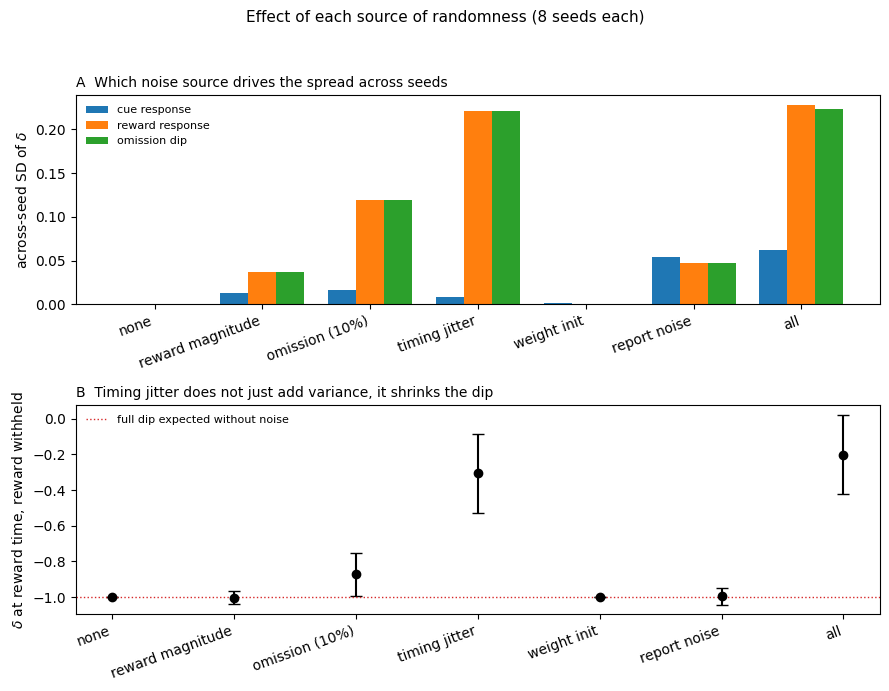

In [7]:
def fig_noise_ablation(cfg):
    """Across-seed spread of the trained responses, one noise source at a time."""
    conditions = {"none": (), **{name: (name,) for name in NOISE_SOURCES},
                  "all": tuple(NOISE_SOURCES)}

    readouts = {}
    for label, names in conditions.items():
        noisy = with_noise(cfg, *names) if names else cfg
        runs = [run(noisy, seed) for seed in SEEDS]
        readouts[label] = np.array([
            [r.trained[cfg.cue_times[0]], r.trained[cfg.reward_time], r.omission[cfg.reward_time]]
            for r in runs
        ])

    labels = list(conditions)
    x = np.arange(len(labels))
    names = ("cue response", "reward response", "omission dip")

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(9.0, 7.0))

    width = 0.26
    for i, name in enumerate(names):
        spread = [readouts[label][:, i].std() for label in labels]
        top.bar(x + (i - 1) * width, spread, width, label=name)
    top.set_xticks(x, labels, rotation=20, ha="right")
    top.set_ylabel(r"across-seed SD of $\delta$")
    top.set_title("A  Which noise source drives the spread across seeds", loc="left", fontsize=10)
    top.legend(fontsize=8, frameon=False)

    dip = np.array([readouts[label][:, 2] for label in labels])
    bottom.errorbar(x, dip.mean(axis=1), yerr=dip.std(axis=1), fmt="o", capsize=4, color="k")
    bottom.axhline(-cfg.reward_size, color="tab:red", ls=":", lw=1,
                   label="full dip expected without noise")
    bottom.set_xticks(x, labels, rotation=20, ha="right")
    bottom.set_ylabel(r"$\delta$ at reward time, reward withheld")
    bottom.set_title("B  Timing jitter does not just add variance, it shrinks the dip",
                     loc="left", fontsize=10)
    bottom.legend(fontsize=8, frameon=False)

    fig.suptitle(f"Effect of each source of randomness ({len(SEEDS)} seeds each)", fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig, readouts


fig, readouts = fig_noise_ablation(Config())
fig.savefig(FIGURES / "noise_ablation.png", dpi=200)

jittered = readouts["timing jitter"][:, 2]
print(f"omission dip under +/-2 step jitter: {jittered.mean():+.3f} +/- {jittered.std():.3f}"
      "   (fixed point predicts -0.200)")

---

# The discount factor is not a free parameter here

Everything above ran at $\gamma = 1$. That is forced, not chosen: the value surface in the paper's Fig. 3 saturates at 1 across all delays, which is only possible with no discounting at all.

It matters more than it looks. Over an interval of $\Delta = 50$ steps between cue and reward, a fully learned value at the cue is worth

$$\hat{V}(s+1) \;=\; \gamma^{\,\Delta}\, r \qquad\Longrightarrow\qquad \delta(s) \;\approx\; \gamma^{\,\Delta}$$

so the transferred cue response is not merely reduced by discounting, it is reduced *geometrically in the interval*. At $\gamma = 0.98$ — a value nobody would blink at — the response is down to 0.36, and at $\gamma = 0.9$ it is 0.005, effectively gone. The cell below confirms the predicted $\gamma^{50}$ scaling.

Worth stating plainly, because the figure is often read as showing a full-size transfer of the response from reward to cue: that full size depends on the model not discounting at all across a 50-step gap.

In [8]:
gap = Config().reward_time - Config().cue_times[0]
print(f"cue-to-reward interval: {gap} steps\n")
print("gamma   cue response   gamma^interval")
for g in (1.0, 0.99, 0.98, 0.95, 0.9):
    trained = run(replace(Config(), gamma=g), seed=0).trained
    print(f"{g:5.2f}   {trained[10]:+.4f}        {g ** gap:.4f}")

cue-to-reward interval: 50 steps

gamma   cue response   gamma^interval
 1.00   +0.9866        1.0000
 0.99   +0.5969        0.6050
 0.98   +0.3593        0.3642
 0.95   +0.0759        0.0769
 0.90   +0.0051        0.0052


---

# Two things that quietly break it

Both of these look like harmless implementation choices and are not.

**1. Starting the serial compound at $\tau = 0$.** As argued near the top, giving the cue a component at its own onset lets $w^i_0$ learn the prediction, $\hat V(s)$ rises to meet $\gamma \hat V(s+1)$, and the cue response disappears. The omission dip survives untouched, so the failure is silent unless you look at the right panel.

**2. A learning rate above 0.5 — but only with two cues.** Both compounds are active at the same time steps once $t > 20$, so each of those time steps is effectively updated twice per trial. The per-step contraction is $1 - n_{\text{cues}}\alpha$ and stability needs

$$n_{\text{cues}} \cdot \alpha < 1$$

With one cue $\alpha = 1$ is perfectly stable; with two it diverges to $10^{36}$. Nothing in Eq. 5 warns you, because the paper writes the update for a single cue and says the rest is summation.

There was also a third, of a more ordinary kind: `np.take(w, delays)` instead of `np.take_along_axis` silently flattens the weight matrix and indexes the wrong cue's weights. It ran, produced a plausible-looking trained trace with a peak at $t=66$, and made the omission response come out *positive*. Checking that the omission case must be negative, on principle rather than by eye, is what caught it.

In [9]:
cfg = Config()

# 1. What if the serial compound also has a component at the cue's own onset?
t = np.arange(cfg.n_steps)
from_zero = np.stack([t - onset for onset in cfg.cue_times])
from_zero = np.where((from_zero >= 0) & (from_zero < cfg.n_steps), from_zero, -1)

w = np.zeros((len(cfg.cue_times), cfg.n_steps))
for _ in range(cfg.n_trials):
    w += trial(w, cfg, from_zero, cfg.reward_time, cfg.reward_size)[2]
_, trained, _ = trial(w, cfg, from_zero, cfg.reward_time, cfg.reward_size)
_, omission, _ = trial(w, cfg, from_zero, None, cfg.reward_size)

reference = run(cfg, seed=0)
print("cue response   tau>=1 (correct): %+.3f    tau>=0: %+.3f" % (reference.trained[10], trained[10]))
print("omission dip   tau>=1 (correct): %+.3f    tau>=0: %+.3f" % (reference.omission[60], omission[60]))

# 2. Stability of the learning rate, one cue versus two.
print("\n                 max |V| reached during training")
print("alpha        one cue          two cues")
for a in (0.4, 0.5, 0.9, 1.0):
    peaks = [np.abs(run(replace(cfg, cue_times=cues, alpha=a, n_trials=200), 0).values).max()
             for cues in ((10,), (10, 20))]
    print(f"{a:4.1f}   {peaks[0]:14.3g}   {peaks[1]:14.3g}")

cue response   tau>=1 (correct): +0.987    tau>=0: +0.008
omission dip   tau>=1 (correct): -1.000    tau>=0: -1.000

                 max |V| reached during training
alpha        one cue          two cues
 0.4                1                1
 0.5                1                1
 0.9                1         1.05e+36
 1.0                1         2.01e+53


---

# Where this leaves things

The replication succeeds: all three response patterns appear, the response transfers to the earliest cue and not the second, and the reward's timing is learned long before the cue acquires its response — every qualitative claim the paper makes about the model.

The two places it departs from the published figure both come from the same place, the temporal representation. A serial compound is a perfect stopwatch, and the figure's cleanest features are the ones that depend on owning one: a full-size cue response requires no discounting across 50 steps, and a full-depth omission dip requires knowing the interval to the step. Loosen the clock by $\pm 2$ steps and the dip falls to a fifth of its size, exactly as the fixed point says it must.

**What I would do next.** Swap the serial compound for a microstimulus representation (Ludvig, Sutton & Kehoe 2008) — a coarse basis of overlapping, temporally blurred features rather than one weight per exact delay — and rerun the jitter ablation above unchanged. A representation that spreads its prediction over neighbouring time steps should degrade far more gracefully under interval jitter, and it is a direct test of whether the fragility here belongs to the *representation* or to TD learning itself. Given that the lab's interest is in whether prefrontal-inspired structure helps agents cope with situations they were not trained on, "the reward came two steps late" is about the smallest such situation available, and this model already fails it.